In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [44]:
# Load the datasets

DATA_DIR = Path("../data")

skills = pd.read_csv(DATA_DIR / "skills_rows.csv")
vacancies = pd.read_csv(DATA_DIR / "vacancies_rows.csv")
vacancy_skills = pd.read_csv(DATA_DIR / "vacancy_skills_rows.csv")

print("Datasets loaded successfully!")
print()
print("Skills:", skills.shape)

print("Vacancies:", vacancies.shape)
print("Vacancy-Skills:", vacancy_skills.shape)

Datasets loaded successfully!

Skills: (2033, 3)
Vacancies: (2154, 10)
Vacancy-Skills: (13032, 2)


In [45]:
# Display the first 5 rows of each dataset

print("=== SKILLS ===")
display(skills.head())

print("\n=== VACANCIES ===")
display(vacancies.head())

print("\n=== VACANCY-SKILLS MAPPING ===")
display(vacancy_skills.head())

=== SKILLS ===


,id,created_at,name
0,1,2026-03-19 11:24:51.895497+00,SQL
1,2,2026-03-19 11:24:51.909554+00,Agile
2,3,2026-03-19 11:24:51.948616+00,ERP Systems
3,4,2026-03-19 11:24:51.987942+00,Issue Tracking
4,5,2026-03-19 11:24:52.016191+00,Snowflake



=== VACANCIES ===


,id,created_at,title,company,source_url,description_raw,experience_years,published_at,location,experience_level
0,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN
1,2,2026-03-19 00:00:00+00,Data Analyst,Go Offer,https://www.linkedin.com/jobs/view/data-analys...,Join Go Offer as a Data Analyst with Russian l...,2.0,NaN,NaN,NaN
2,3,2026-03-19 00:00:00+00,Data Analyst (f/m/d),ITRex Group,https://pl.linkedin.com/jobs/view/data-analyst...,About ITRex\n\nTHE PLACE\n\nITRex - AI pioneer...,4.0,NaN,NaN,NaN
3,4,2026-03-19 00:00:00+00,Data Analyst - Fully Remote,Haystack,https://uk.linkedin.com/jobs/view/data-analyst...,Data Analyst\n\nWe're working with a leading g...,0.0,NaN,NaN,NaN
4,5,2026-03-19 00:00:00+00,Data Analyst | Remote,Crossing Hurdles,https://uk.linkedin.com/jobs/view/data-analyst...,Position: Join Expert Network: Business Intell...,0.0,NaN,NaN,NaN



=== VACANCY-SKILLS MAPPING ===


,vacancy_id,skill_id
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5


In [46]:
# Merge vacancies with the vacancy-skill mapping
master = vacancy_skills.merge(
    vacancies,
    left_on="vacancy_id",
    right_on="id",
    how="left"
)

# Merge with the skills table
master = master.merge(
    skills,
    left_on="skill_id",
    right_on="id",
    how="left",
    suffixes=("_vacancy", "_skill")
)

print("Master dataset created!")
print("Shape:", master.shape)

display(master.head())

Master dataset created!
Shape: (13032, 15)


,vacancy_id,skill_id,id_vacancy,created_at_vacancy,title,company,source_url,description_raw,experience_years,published_at,location,experience_level,id_skill,created_at_skill,name
0,1,1,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN,1,2026-03-19 11:24:51.895497+00,SQL
1,1,2,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN,2,2026-03-19 11:24:51.909554+00,Agile
2,1,3,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN,3,2026-03-19 11:24:51.948616+00,ERP Systems
3,1,4,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN,4,2026-03-19 11:24:51.987942+00,Issue Tracking
4,1,5,1,2026-03-19 00:00:00+00,Data Analyst,CRG,https://www.linkedin.com/jobs/view/data-analys...,Data Analyst\n\n\n\n\nDuration: 6-month contra...,3.0,NaN,NaN,NaN,5,2026-03-19 11:24:52.016191+00,Snowflake


In [47]:
# Select the important columns for analysis

master = master[
    [
        "vacancy_id",
        "title",
        "company",
        "experience_years",
        "published_at",
        "location",
        "experience_level",
        "skill_id",
        "name"
    ]
].copy()

# Rename skill column
master = master.rename(columns={"name": "skill"})

# Convert published date to datetime
master["published_at"] = pd.to_datetime(
    master["published_at"],
    errors="coerce"
)

print("Clean master dataset created!")
print("Shape:", master.shape)

display(master.head())

Clean master dataset created!
Shape: (13032, 9)


,vacancy_id,title,company,experience_years,published_at,location,experience_level,skill_id,skill
0,1,Data Analyst,CRG,3.0,NaT,NaN,NaN,1,SQL
1,1,Data Analyst,CRG,3.0,NaT,NaN,NaN,2,Agile
2,1,Data Analyst,CRG,3.0,NaT,NaN,NaN,3,ERP Systems
3,1,Data Analyst,CRG,3.0,NaT,NaN,NaN,4,Issue Tracking
4,1,Data Analyst,CRG,3.0,NaT,NaN,NaN,5,Snowflake


In [48]:
# Top demanded skills

skill_demand = (
    master.groupby("skill")["vacancy_id"]
    .nunique()
    .sort_values(ascending=False)
)

top_15_skills = skill_demand.head(15)

print("Top 15 Most Demanded Skills:")
display(top_15_skills)

Top 15 Most Demanded Skills:


skill
SQL                     1298
Python                   760
Excel                    692
Tableau                  685
Power BI                 568
R                        395
Data Visualization       248
Data Analysis            207
SAS                      169
Data Modeling            166
Looker                   145
Snowflake                127
Microsoft Excel          121
Statistical Analysis     114
AWS                      111
Name: vacancy_id, dtype: int64

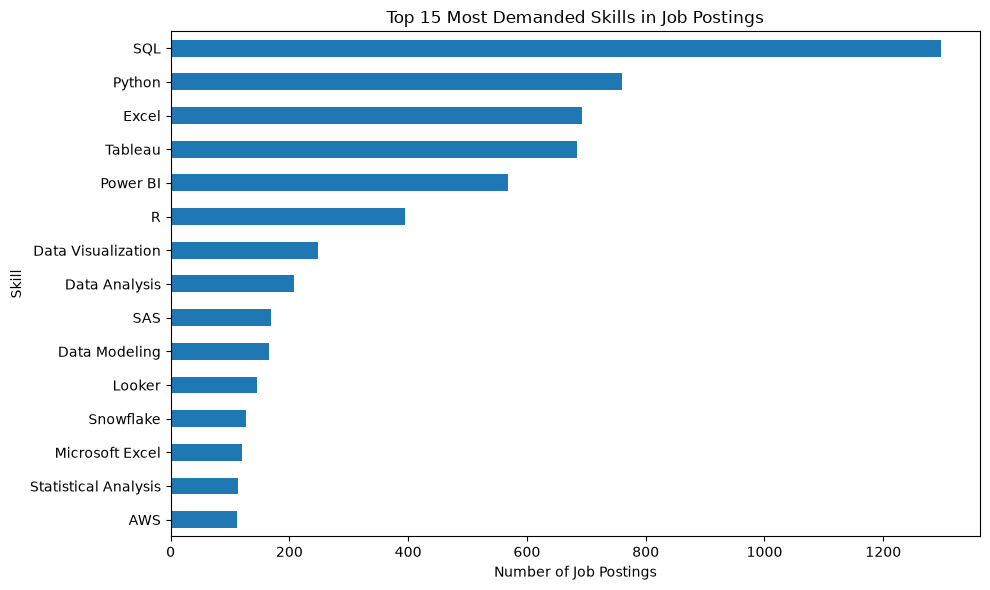

In [49]:
# Visualization 1: Top 15 demanded skills

plt.figure(figsize=(10, 6))

top_15_skills.sort_values().plot(kind="barh")

plt.title("Top 15 Most Demanded Skills in Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()

plt.show()

In [50]:
# Find skills containing common spreadsheet-related terms

excel_skills = skills[
    skills["name"].str.contains("excel", case=False, na=False)
]

display(excel_skills)

,id,created_at,name
10,12,2026-03-19 11:24:53.32117+00,Excel
82,123,2026-03-19 11:25:04.989804+00,Microsoft Excel
256,981,2026-03-21 21:21:29.684894+00,MS Excel
1521,11045,2026-03-22 11:59:53.280786+00,Excel Formulas
1539,11127,2026-03-22 12:00:35.976457+00,Excel Modeling


In [51]:
# Normalize obvious Excel naming variants

skill_name_map = {
    "Microsoft Excel": "Excel",
    "MS Excel": "Excel"
}

master["skill_normalized"] = master["skill"].replace(skill_name_map)

# Recalculate skill demand using normalized names
normalized_skill_demand = (
    master.groupby("skill_normalized")["vacancy_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("Top 15 skills after normalization:")
display(normalized_skill_demand.head(15))

Top 15 skills after normalization:


skill_normalized
SQL                     1298
Excel                    825
Python                   760
Tableau                  685
Power BI                 568
R                        395
Data Visualization       248
Data Analysis            207
SAS                      169
Data Modeling            166
Looker                   145
Snowflake                127
Statistical Analysis     114
AWS                      111
PowerPoint               110
Name: vacancy_id, dtype: int64

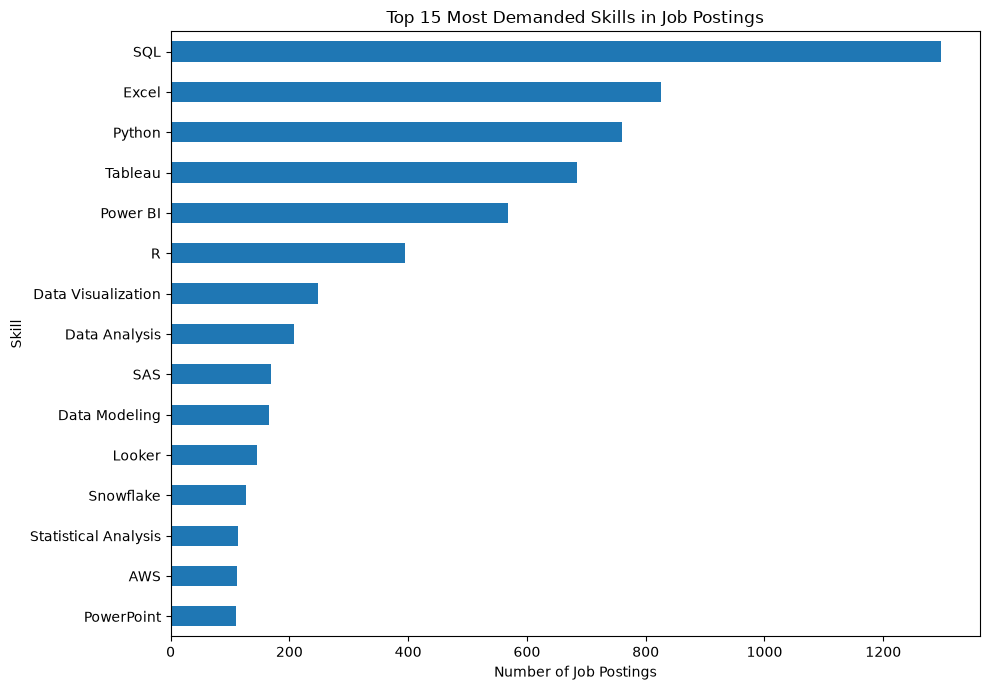

In [52]:
# Visualization 1: Top 15 demanded skills after normalization

top_15_normalized = normalized_skill_demand.head(15)

plt.figure(figsize=(10, 7))

top_15_normalized.sort_values().plot(kind="barh")

plt.title("Top 15 Most Demanded Skills in Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [53]:
# Calculate percentage of job postings requiring each skill

total_vacancies = vacancies["id"].nunique()

top_15_percentage = (
    top_15_normalized
    .to_frame("job_postings")
)

top_15_percentage["percentage"] = (
    top_15_percentage["job_postings"] / total_vacancies * 100
).round(2)

display(top_15_percentage)

,job_postings,percentage
skill_normalized,,
SQL,1298,60.26
Excel,825,38.30
Python,760,35.28
Tableau,685,31.80
Power BI,568,26.37
R,395,18.34
Data Visualization,248,11.51
Data Analysis,207,9.61
SAS,169,7.85


In [54]:
# Check the available experience levels

experience_levels = (
    vacancies["experience_level"]
    .value_counts(dropna=False)
)

display(experience_levels)

experience_level
Not specified       947
Middle              368
Entry level         271
Senior              229
Junior              119
Not Applicable       89
Mid-Senior level     53
Lead                 29
Associate            28
NaN                  16
Internship            5
Name: count, dtype: int64

In [55]:
# Prepare data for skill demand by experience level

valid_levels = [
    "Internship",
    "Entry level",
    "Junior",
    "Associate",
    "Middle",
    "Mid-Senior level",
    "Senior",
    "Lead"
]

experience_skill_data = master[
    master["experience_level"].isin(valid_levels)
].copy()

# Count unique job postings requiring each skill at each experience level
skill_experience = pd.crosstab(
    experience_skill_data["skill_normalized"],
    experience_skill_data["experience_level"]
)

# Keep the 10 most demanded skills overall
top_10_skills = normalized_skill_demand.head(10).index

skill_experience_top10 = skill_experience.loc[
    skill_experience.index.intersection(top_10_skills)
]

display(skill_experience_top10)

experience_level,Associate,Entry level,Internship,Junior,Lead,Mid-Senior level,Middle,Senior
skill_normalized,,,,,,,,
Data Analysis,10,31,3,12,3,15,49,36
Data Modeling,10,13,0,10,3,12,53,37
Data Visualization,15,30,1,15,3,14,69,45
Excel,16,174,4,64,8,19,166,71
Power BI,13,58,2,44,4,25,128,77
Python,12,60,4,39,7,23,162,97
R,4,24,2,17,5,10,98,58
SAS,0,8,0,7,3,1,47,29
SQL,22,134,3,76,15,40,290,187


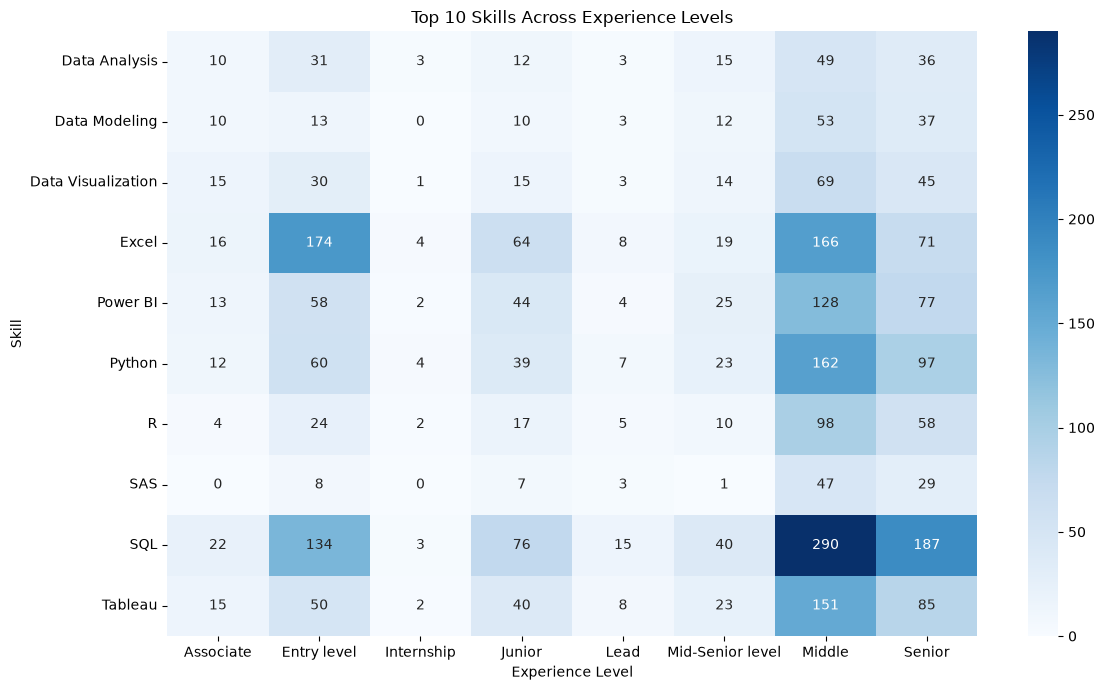

In [56]:
# Visualization 2: Skill demand across experience levels

plt.figure(figsize=(12, 7))

sns.heatmap(
    skill_experience_top10,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Top 10 Skills Across Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

In [57]:

from itertools import combinations
from collections import Counter

# Create unique skill sets for each job posting
job_skill_sets = (
    master.groupby("vacancy_id")["skill_normalized"]
    .apply(lambda x: sorted(set(x.dropna())))
)

# Count skill pairs appearing in the same job posting
skill_pairs = Counter()

for skill_list in job_skill_sets:
    for pair in combinations(skill_list, 2):
        skill_pairs[pair] += 1

# Convert to DataFrame
skill_pairs_df = pd.DataFrame(
    skill_pairs.items(),
    columns=["skill_pair", "job_postings"]
)

skill_pairs_df = skill_pairs_df.sort_values(
    "job_postings",
    ascending=False
).reset_index(drop=True)

print("Top 15 Skill Combinations:")
display(skill_pairs_df.head(15))

Top 15 Skill Combinations:


,skill_pair,job_postings
0,"(Python, SQL)",649
1,"(SQL, Tableau)",579
2,"(Excel, SQL)",512
3,"(Power BI, SQL)",446
4,"(Python, Tableau)",365
5,"(Python, R)",354
6,"(R, SQL)",328
7,"(Power BI, Tableau)",305
8,"(Excel, Power BI)",298
9,"(Excel, Tableau)",287


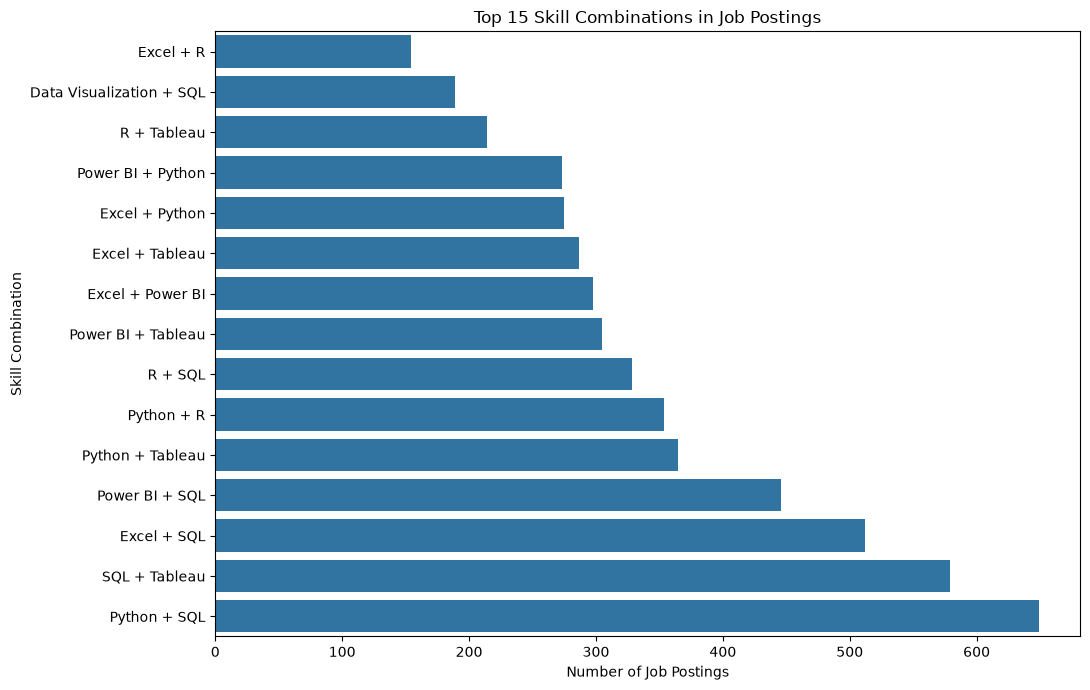

In [58]:
# Visualization 3: Most common skill combinations

top_pairs = skill_pairs_df.head(15).copy()

top_pairs["skill_pair"] = top_pairs["skill_pair"].apply(
    lambda x: " + ".join(x)
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_pairs.sort_values("job_postings"),
    x="job_postings",
    y="skill_pair"
)

plt.title("Top 15 Skill Combinations in Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill Combination")

plt.tight_layout()
plt.show()

In [59]:
# Prepare monthly skill demand

trend_data = master.dropna(subset=["published_at"]).copy()

trend_data["month"] = trend_data["published_at"].dt.to_period("M").astype(str)

# Select major skills
trend_skills = ["SQL", "Python", "Excel", "Tableau", "Power BI"]

monthly_skill_demand = (
    trend_data[trend_data["skill_normalized"].isin(trend_skills)]
    .groupby(["month", "skill_normalized"])["vacancy_id"]
    .nunique()
    .unstack(fill_value=0)
)

display(monthly_skill_demand.head(10))

skill_normalized,Excel,Power BI,Python,SQL,Tableau
month,,,,,
2022-09,0,0,1,1,1
2022-10,9,8,18,25,9
2022-11,45,25,29,69,32
2022-12,37,21,24,70,33
2023-01,31,16,27,49,24
2023-02,34,19,31,55,29
2023-03,47,20,29,55,24
2023-04,42,28,36,52,29
2023-05,39,20,38,49,21


In [60]:
# Generate role-specific skill profiles for the backend

import json
from pathlib import Path

role_skill_profiles = {}

role_counts = master["title"].value_counts()

# Use roles with at least 20 job postings
common_roles = role_counts[role_counts >= 20].index.tolist()

for role in common_roles:
    role_data = master[
        master["title"].str.lower() == role.lower()
    ].copy()

    role_skill_counts = (
        role_data.groupby("skill_normalized")["vacancy_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(15)
    )

    role_skill_profiles[role] = [
        {
            "skill": str(skill),
            "job_postings": int(count)
        }
        for skill, count in role_skill_counts.items()
    ]

output_path = Path("../role_skill_profiles.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(role_skill_profiles, f, indent=4)

print("Role-specific skill profiles created successfully!")
print("Number of roles:", len(role_skill_profiles))
print("Saved to:", output_path)

Role-specific skill profiles created successfully!
Number of roles: 82
Saved to: ..\role_skill_profiles.json


In [61]:
# Visualization 5: Role vs skill demand

plt.figure(figsize=(12, 7))

sns.heatmap(
    role_skill_top,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Top Skills Across Common Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

NameError: name 'role_skill_top' is not defined

<Figure size 1200x700 with 0 Axes>

In [ ]:
# Skill Gap Engine

def get_role_skills(role, top_n=10):
    role_data = master[
        master["title"].str.lower() == role.lower()
    ].copy()

    if role_data.empty:
        return pd.DataFrame()

    role_skills = (
        role_data.groupby("skill_normalized")["vacancy_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    role_skills.columns = ["skill", "job_postings"]

    return role_skills


# Example: analyze the Data Analyst role
data_analyst_skills = get_role_skills("Data Analyst", top_n=15)

display(data_analyst_skills)

,skill,job_postings
0,SQL,468
1,Excel,280
2,Python,258
3,Tableau,241
4,Power BI,221
5,R,121
6,Data Visualization,91
7,Data Analysis,75
8,Data Modeling,65
9,Looker,51


In [ ]:
def calculate_skill_gap(target_role, user_skills, top_n=15):
    role_skills = get_role_skills(target_role, top_n)

    if role_skills.empty:
        return {
            "error": f"No exact job title found for '{target_role}'"
        }

    user_skills_normalized = {
        skill.strip().lower()
        for skill in user_skills
    }

    role_skills["status"] = role_skills["skill"].apply(
        lambda skill: (
            "Have"
            if skill.lower() in user_skills_normalized
            else "Gap"
        )
    )

    return role_skills


# Example input
example_skills = ["SQL", "Python"]

gap_result = calculate_skill_gap(
    "Data Analyst",
    example_skills
)

display(gap_result)

,skill,job_postings,status
0,SQL,468,Have
1,Excel,280,Gap
2,Python,258,Have
3,Tableau,241,Gap
4,Power BI,221,Gap
5,R,121,Gap
6,Data Visualization,91,Gap
7,Data Analysis,75,Gap
8,Data Modeling,65,Gap
9,Looker,51,Gap


In [ ]:
def calculate_skill_match(target_role, user_skills, top_n=15):
    result = calculate_skill_gap(target_role, user_skills, top_n)

    if isinstance(result, dict):
        return result

    total_skills = len(result)
    matched_skills = (result["status"] == "Have").sum()

    match_percentage = round(
        (matched_skills / total_skills) * 100,
        2
    )

    return {
        "role": target_role,
        "match_percentage": match_percentage,
        "matched_skills": result[result["status"] == "Have"]["skill"].tolist(),
        "skill_gaps": result[result["status"] == "Gap"]["skill"].tolist()
    }


# Example
match_result = calculate_skill_match(
    "Data Analyst",
    ["SQL", "Python"]
)

print(match_result)

{'role': 'Data Analyst', 'match_percentage': np.float64(13.33), 'matched_skills': ['SQL', 'Python'], 'skill_gaps': ['Excel', 'Tableau', 'Power BI', 'R', 'Data Visualization', 'Data Analysis', 'Data Modeling', 'Looker', 'AWS', 'ETL', 'Snowflake', 'Reporting', 'SAS']}


In [ ]:
def calculate_weighted_skill_match(target_role, user_skills, top_n=15):
    result = calculate_skill_gap(target_role, user_skills, top_n)

    if isinstance(result, dict):
        return result

    user_skills_normalized = {
        skill.strip().lower()
        for skill in user_skills
    }

    total_demand = result["job_postings"].sum()

    matched_demand = result[
        result["skill"].str.lower().isin(user_skills_normalized)
    ]["job_postings"].sum()

    weighted_match = round(
        (matched_demand / total_demand) * 100,
        2
    )

    return {
        "role": target_role,
        "weighted_match_percentage": weighted_match,
        "matched_skills": result[
            result["skill"].str.lower().isin(user_skills_normalized)
        ]["skill"].tolist(),
        "skill_gaps": result[
            ~result["skill"].str.lower().isin(user_skills_normalized)
        ]["skill"].tolist()
    }


# Example
weighted_result = calculate_weighted_skill_match(
    "Data Analyst",
    ["SQL", "Python"]
)

print(weighted_result)

{'role': 'Data Analyst', 'weighted_match_percentage': np.float64(34.47), 'matched_skills': ['SQL', 'Python'], 'skill_gaps': ['Excel', 'Tableau', 'Power BI', 'R', 'Data Visualization', 'Data Analysis', 'Data Modeling', 'Looker', 'AWS', 'ETL', 'Snowflake', 'Reporting', 'SAS']}


In [ ]:
import json

# Build backend-ready career intelligence result

backend_result = {
    "role": weighted_result["role"],
    "match_percentage": float(weighted_result["weighted_match_percentage"]),
    "matched_skills": weighted_result["matched_skills"],
    "skill_gaps": weighted_result["skill_gaps"],

    "top_demanded_skills": [
        {
            "skill": str(skill),
            "job_postings": int(count)
        }
        for skill, count in normalized_skill_demand.head(15).items()
    ],

    "top_skill_combinations": [
        {
            "skills": " + ".join(pair),
            "job_postings": int(count)
        }
        for pair, count in skill_pairs_df.head(15).itertuples(index=False)
    ]
}

# Save as JSON
output_path = Path("../career_intelligence_output.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(backend_result, f, indent=4)

print("Backend output created successfully!")
print("Saved to:", output_path)

Backend output created successfully!
Saved to: ..\career_intelligence_output.json


In [ ]:
import pandas as pd
from pathlib import Path

# Load dataset files
data_path = Path("../data")

skills = pd.read_csv(data_path / "skills_rows.csv")
vacancies = pd.read_csv(data_path / "vacancies_rows.csv")
vacancy_skills = pd.read_csv(data_path / "vacancy_skills_rows.csv")

# Merge vacancy + skills data
master = vacancy_skills.merge(
    vacancies,
    left_on="vacancy_id",
    right_on="id",
    how="left"
)

master = master.merge(
    skills,
    left_on="skill_id",
    right_on="id",
    how="left",
    suffixes=("_vacancy", "_skill")
)

master = master[
    [
        "vacancy_id",
        "title",
        "company",
        "experience_years",
        "published_at",
        "location",
        "experience_level",
        "skill_id",
        "name"
    ]
].copy()

master = master.rename(columns={"name": "skill"})

master["published_at"] = pd.to_datetime(
    master["published_at"],
    errors="coerce"
)

# Normalize Excel skill names
skill_name_map = {
    "Microsoft Excel": "Excel",
    "MS Excel": "Excel"
}

master["skill_normalized"] = master["skill"].replace(skill_name_map)

print("Master dataset created!")
print("Rows:", len(master))
print(master.head())

Master dataset created!
Rows: 13032
   vacancy_id         title company  experience_years published_at location  \
0           1  Data Analyst     CRG               3.0          NaT      NaN   
1           1  Data Analyst     CRG               3.0          NaT      NaN   
2           1  Data Analyst     CRG               3.0          NaT      NaN   
3           1  Data Analyst     CRG               3.0          NaT      NaN   
4           1  Data Analyst     CRG               3.0          NaT      NaN   

  experience_level  skill_id           skill skill_normalized  
0              NaN         1             SQL              SQL  
1              NaN         2           Agile            Agile  
2              NaN         3     ERP Systems      ERP Systems  
3              NaN         4  Issue Tracking   Issue Tracking  
4              NaN         5       Snowflake        Snowflake  


In [ ]:
import json
from pathlib import Path

role_skill_profiles = {}

role_counts = master["title"].value_counts()
common_roles = role_counts[role_counts >= 20].index.tolist()

for role in common_roles:
    role_data = master[
        master["title"].str.lower() == role.lower()
    ].copy()

    role_skill_counts = (
        role_data.groupby("skill_normalized")["vacancy_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(15)
    )

    role_skill_profiles[role] = [
        {
            "skill": str(skill),
            "job_postings": int(count)
        }
        for skill, count in role_skill_counts.items()
    ]

output_path = Path("../role_skill_profiles.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(role_skill_profiles, f, indent=4)

print("Role-specific skill profiles created!")
print("Number of roles:", len(role_skill_profiles))
print("Saved to:", output_path)

Role-specific skill profiles created!
Number of roles: 82
Saved to: ..\role_skill_profiles.json
